# Predicting Machine Failure Using Explainable Machine Learning

**Project type:** Binary classification  
**Dataset:** AI4I 2020 Predictive Maintenance Dataset  
**Target variable:** `machine_failure`

## Introduction

Predictive maintenance is an important machine learning application because unexpected machine failures can lead to production downtime, higher repair costs, lower product quality, and operational risk. Instead of reacting only after a machine breaks, predictive maintenance tries to identify warning signals earlier, using information from operating conditions and machine usage.

In this project, we use the **AI4I 2020 Predictive Maintenance Dataset** from the UCI Machine Learning Repository. According to UCI, the dataset is synthetic but was designed to reflect real predictive maintenance data encountered in industry. This makes it useful for building and explaining a classification model in a controlled setting, while still keeping the variables understandable from an industrial point of view.

The main goal is to predict whether a machine fails in a given observation. Because this is an Explainable AI project, we are not only interested in model performance, but also in understanding which operating conditions are most related to predicted failure risk.

## Project Aim

The aim of this project is to build and explain machine learning models that classify whether a machine failure occurs. The target variable is `machine_failure`, coded as 0 for no failure and 1 for failure.

In the project we want to compare different classification models, select the best one, and use Explainable AI methods to understand how machine conditions such as temperature, rotational speed, torque, tool wear, and product type influence predicted failure risk.

## Dataset Description

The dataset used in this project is the **AI4I 2020 Predictive Maintenance Dataset** from the UCI Machine Learning Repository. UCI describes it as a synthetic dataset that reflects real predictive maintenance data encountered in industry. The dataset was donated on August 29, 2020.

The local CSV file is stored as `ai4i2020.csv`. It contains **10,000 observations** and **14 original columns**. The main target variable is `Machine failure`, which indicates whether the machine failed in a given datapoint.

**Original feature groups:**

- **Identifiers:** `UDI`, `Product ID`
- **Product quality type:** `Type`, with product variants `L`, `M`, and `H`
- **Operating conditions:** `Air temperature [K]`, `Process temperature [K]`, `Rotational speed [rpm]`, `Torque [Nm]`, `Tool wear [min]`
- **General target:** `Machine failure`
- **Failure-mode indicators:** `TWF`, `HDF`, `PWF`, `OSF`, `RNF`

In the modelling part, we will predict only the general `Machine failure` target. Therefore, the failure-mode variables `TWF`, `HDF`, `PWF`, `OSF`, and `RNF` will be removed during data investigation.

**Main source link:**  
- UCI AI4I 2020 Predictive Maintenance Dataset: https://archive.ics.uci.edu/dataset/601/ai4i%2B2020%2Bpredictive%2Bmaintenance%2Bdataset

## Libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Data Investigation

Before the exploratory data analysis, we first check whether the dataset loads correctly, how many rows and columns it contains, what data types are stored in each column, and whether missing values or duplicates are present. At this stage, we only inspect the data and make the first necessary structural changes.

In [2]:
# Load the dataset
candidate_raw_paths = [
    Path("../data/raw/ai4i2020.csv"),
    Path("classification/data/raw/ai4i2020.csv"),
    Path("data/raw/ai4i2020.csv")
]

raw_data_path = next((path for path in candidate_raw_paths if path.exists()), None)

if raw_data_path is None:
    raise FileNotFoundError("Could not find ai4i2020.csv in the expected raw data folders.")

data_dir = raw_data_path.parent.parent
df = pd.read_csv(raw_data_path)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### Dataset Size

In [3]:
# Check number of rows and columns
rows, columns = df.shape

print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 10000
Number of columns: 14


### Column Names

In [4]:
# Rename columns to make them easier to use in Python
df = df.rename(columns={
    "UDI": "udi",
    "Product ID": "product_id",
    "Type": "type",
    "Air temperature [K]": "air_temperature_k",
    "Process temperature [K]": "process_temperature_k",
    "Rotational speed [rpm]": "rotational_speed_rpm",
    "Torque [Nm]": "torque_nm",
    "Tool wear [min]": "tool_wear_min",
    "Machine failure": "machine_failure",
    "TWF": "twf",
    "HDF": "hdf",
    "PWF": "pwf",
    "OSF": "osf",
    "RNF": "rnf"
})

df.columns

Index(['udi', 'product_id', 'type', 'air_temperature_k',
       'process_temperature_k', 'rotational_speed_rpm', 'torque_nm',
       'tool_wear_min', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf'],
      dtype='str')

### Removing Failure-Mode Columns

In [5]:
# We predict only the general machine_failure target.
# The detailed failure modes are removed because they are directly connected to the target.
failure_mode_columns = ["twf", "hdf", "pwf", "osf", "rnf"]

df = df.drop(columns=failure_mode_columns)
df.head()

,udi,product_id,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


### Column Types

In [6]:
# Check current column types
df.dtypes

udi                        int64
product_id                   str
type                         str
air_temperature_k        float64
process_temperature_k    float64
rotational_speed_rpm       int64
torque_nm                float64
tool_wear_min              int64
machine_failure            int64
dtype: object

In [7]:
# Convert columns that should be treated as categories
df["product_id"] = df["product_id"].astype("category")
df["type"] = df["type"].astype("category")
df["machine_failure"] = df["machine_failure"].astype("int")

df.dtypes

udi                         int64
product_id               category
type                     category
air_temperature_k         float64
process_temperature_k     float64
rotational_speed_rpm        int64
torque_nm                 float64
tool_wear_min               int64
machine_failure             int64
dtype: object

### Missing Values

In [8]:
# Check missing values in each column
missing_values = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

missing_values.sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
udi,0,0.0
product_id,0,0.0
type,0,0.0
air_temperature_k,0,0.0
process_temperature_k,0,0.0
rotational_speed_rpm,0,0.0
torque_nm,0,0.0
tool_wear_min,0,0.0
machine_failure,0,0.0


### Basic Quality Checks

In [9]:
# Check duplicated rows and duplicated IDs
print(f"Duplicated rows: {df.duplicated().sum()}")
print(f"Duplicated UDI values: {df['udi'].duplicated().sum()}")
print(f"Duplicated Product ID values: {df['product_id'].duplicated().sum()}")

# Check target variable values
df["machine_failure"].value_counts(dropna=False)

Duplicated rows: 0
Duplicated UDI values: 0
Duplicated Product ID values: 0


machine_failure
0    9661
1     339
Name: count, dtype: int64

In [10]:
unuseful_columns = ["udi", "product_id"]

df = df.drop(columns=unuseful_columns)
df.head()

,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [11]:
# Quick check of product type values
df["type"].value_counts(dropna=False)

type
L    6000
M    2997
H    1003
Name: count, dtype: int64

## Train / Validation / Test Split

We split the data before EDA and modelling. This is important because the test set should stay untouched until the final evaluation. Since machine failures are rare, we use stratification so that train, validation, and test sets keep a similar percentage of failure cases.

In [12]:
# Separate features and target
X = df.drop(columns="machine_failure")
y = df["machine_failure"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (10000, 6)
Target shape: (10000,)


In [13]:
# Split data into train, validation, and test sets
# Final proportions: 60% train, 20% validation, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [14]:
# Check if stratification worked correctly
split_summary = pd.DataFrame({
    "dataset": ["train", "validation", "test"],
    "rows": [len(y_train), len(y_valid), len(y_test)],
    "failures": [y_train.sum(), y_valid.sum(), y_test.sum()],
    "non_failures": [(y_train == 0).sum(), (y_valid == 0).sum(), (y_test == 0).sum()],
    "failure_rate": [y_train.mean(), y_valid.mean(), y_test.mean()]
})

split_summary["failure_rate"] = (split_summary["failure_rate"] * 100).round(2)
split_summary

,dataset,rows,failures,non_failures,failure_rate
0,train,6000,203,5797,3.38
1,validation,2000,68,1932,3.40
2,test,2000,68,1932,3.40


In [15]:
# Create combined datasets for easier EDA and later checks
train_data = X_train.copy()
train_data["machine_failure"] = y_train

valid_data = X_valid.copy()
valid_data["machine_failure"] = y_valid

test_data = X_test.copy()
test_data["machine_failure"] = y_test

## Exploratory Data Analysis On Training Set

The EDA is performed only on the training set. The validation and test sets remain untouched so that later model selection and final evaluation are fair.

### Target Variable Distribution

In [16]:
# Count failures and non-failures in the training set
target_counts = train_data["machine_failure"].value_counts().sort_index()
target_percent = (train_data["machine_failure"].value_counts(normalize=True).sort_index() * 100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_percent
})

target_summary

,count,percent
machine_failure,,
0,5797,96.62
1,203,3.38


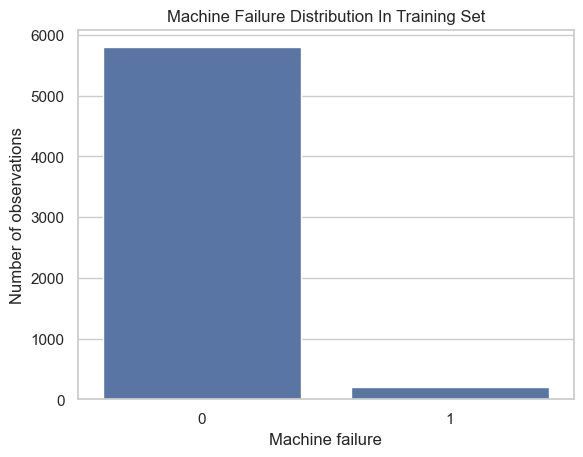

In [17]:
# Plot target distribution
sns.countplot(data=train_data, x="machine_failure")
plt.title("Machine Failure Distribution In Training Set")
plt.xlabel("Machine failure")
plt.ylabel("Number of observations")
plt.show()

### Product Type And Failure Rate

In [18]:
# Check how many observations we have for each product type
train_data["type"].value_counts()

type
L    3636
M    1763
H     601
Name: count, dtype: int64

In [19]:
# Check failure rate by product type
type_failure_rate = train_data.groupby("type", observed=True)["machine_failure"].mean().sort_values(ascending=False)
type_failure_rate = (type_failure_rate * 100).round(2)

type_failure_rate

type
L    4.10
M    2.33
H    2.16
Name: machine_failure, dtype: float64

### Numeric Variable Distributions

In [20]:
numeric_columns = [
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min"
]

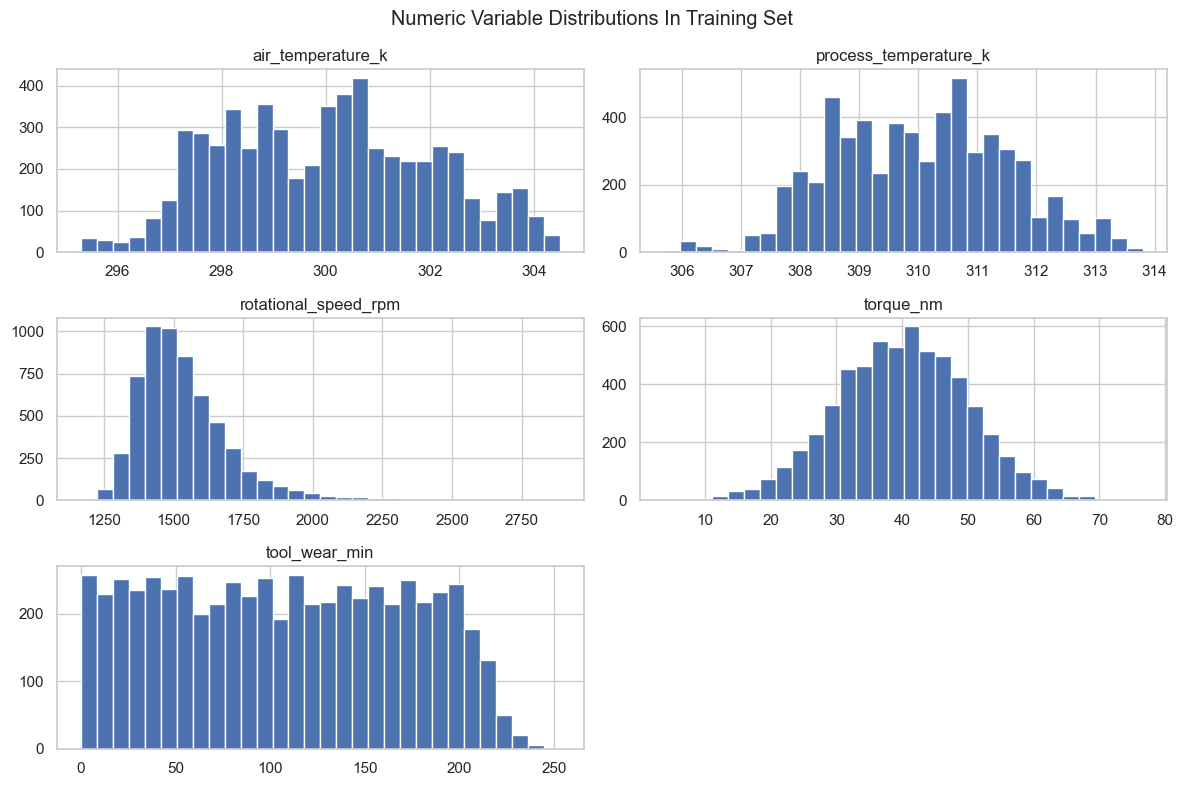

In [21]:
# Plot distributions of numeric variables
train_data[numeric_columns].hist(figsize=(12, 8), bins=30)
plt.suptitle("Numeric Variable Distributions In Training Set")
plt.tight_layout()
plt.show()

### Numeric Variables By Target

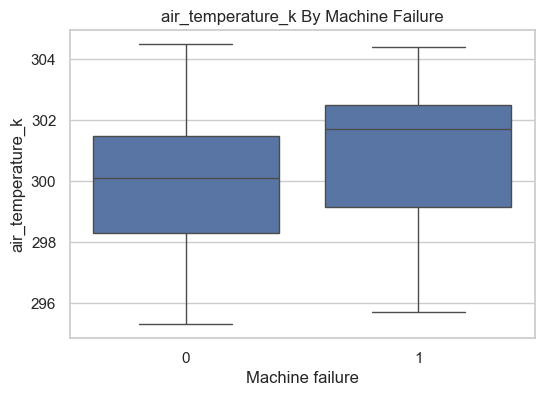

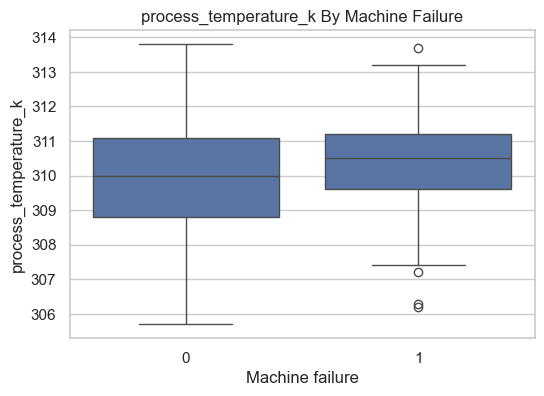

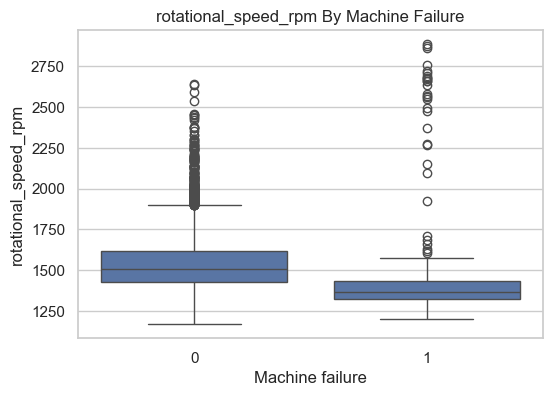

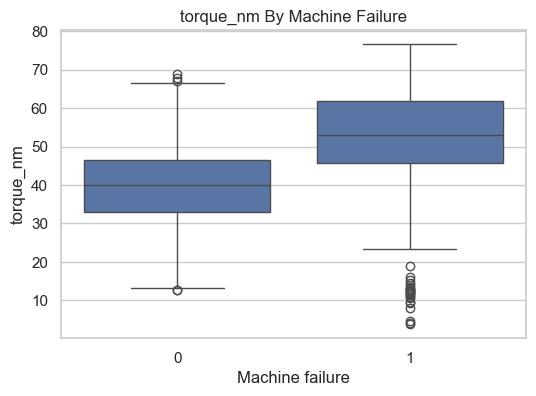

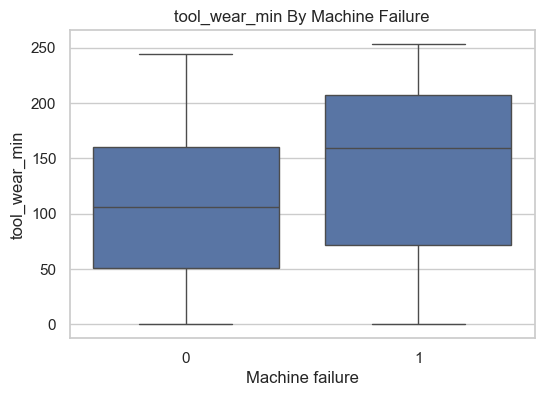

In [22]:
# Compare numeric variables between failure and non-failure observations
for column in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=train_data, x="machine_failure", y=column)
    plt.title(f"{column} By Machine Failure")
    plt.xlabel("Machine failure")
    plt.ylabel(column)
    plt.show()

### Correlation Analysis

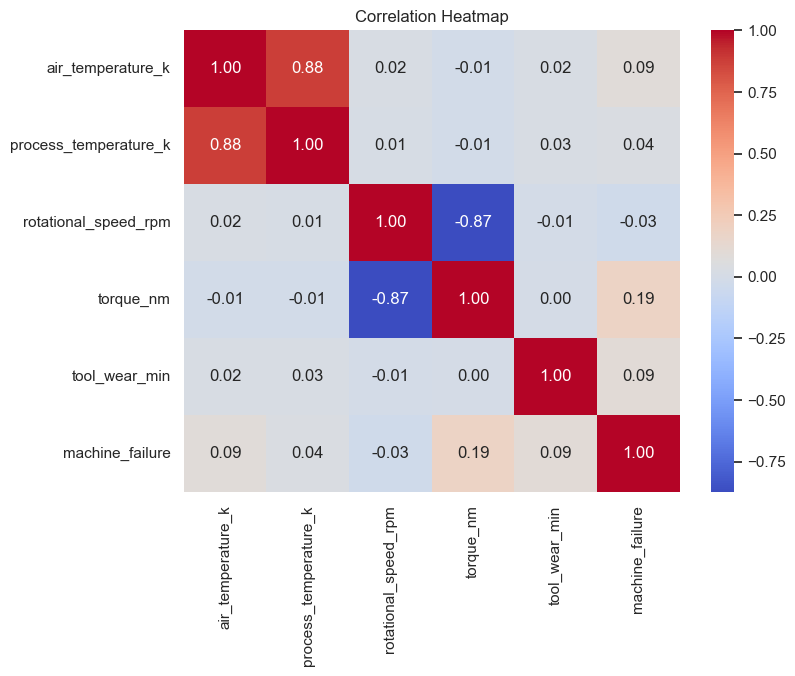

In [23]:
# Correlation between numeric variables and the target
corr_columns = numeric_columns + ["machine_failure"]
correlation_matrix = train_data[corr_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Failure Rate Across Numeric Ranges

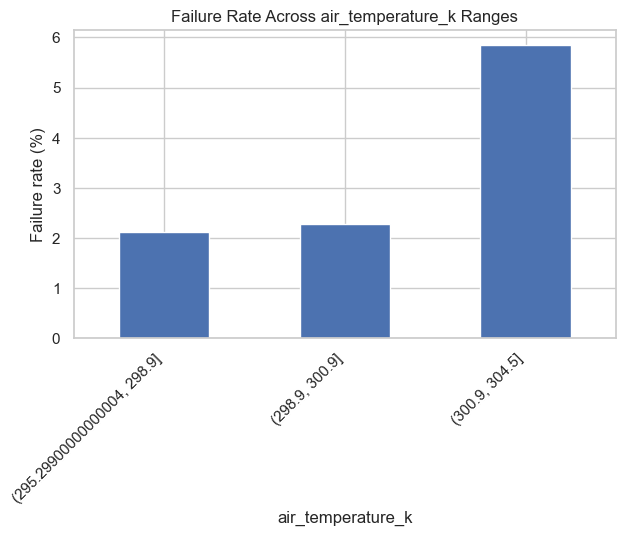

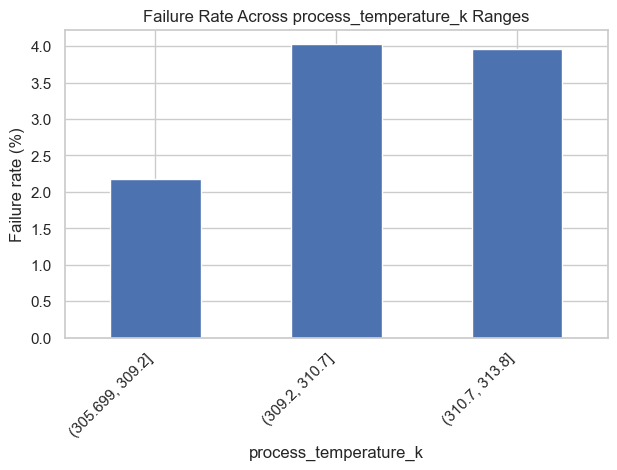

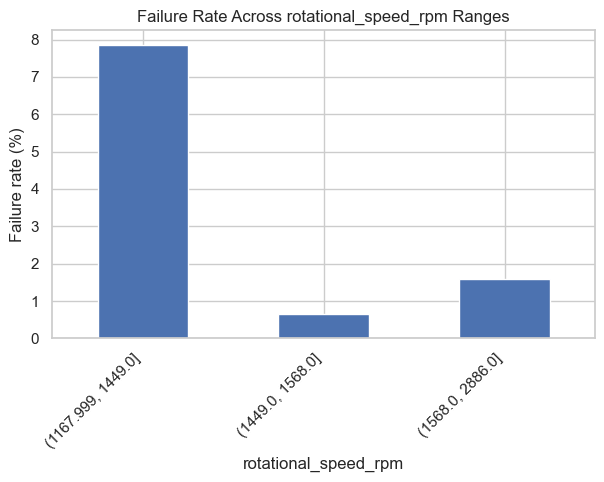

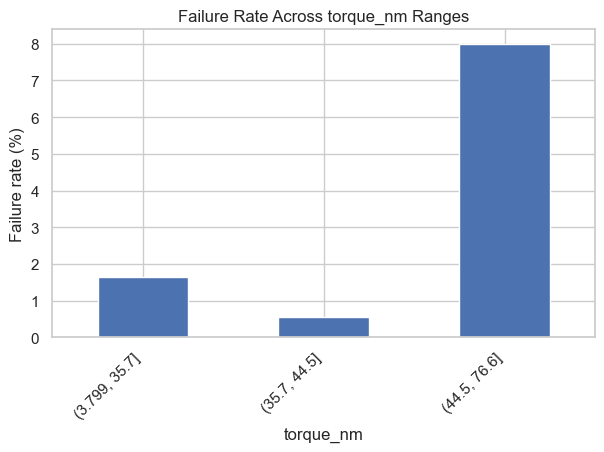

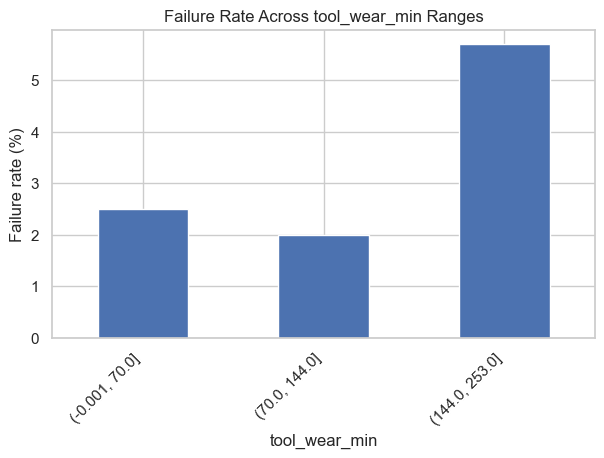

In [24]:
# Check failure rate across low/medium/high ranges of each numeric variable
for column in numeric_columns:
    bin_column = column + "_bin"
    train_data[bin_column] = pd.qcut(train_data[column], q=3, duplicates="drop")

    failure_rate_by_bin = train_data.groupby(bin_column, observed=True)["machine_failure"].mean() * 100

    plt.figure(figsize=(7, 4))
    failure_rate_by_bin.plot(kind="bar")
    plt.title(f"Failure Rate Across {column} Ranges")
    plt.xlabel(column)
    plt.ylabel("Failure rate (%)")
    plt.xticks(rotation=45, ha="right")
    plt.show()

### Extreme Value Check

In [25]:
# Check basic ranges and selected quantiles
train_data[numeric_columns].describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
air_temperature_k,6000.0,300.019783,2.004329,295.3,295.90,297.1,300.1,303.5,304.100,304.5
process_temperature_k,6000.0,310.012383,1.479536,305.7,306.60,307.8,310.1,312.5,313.200,313.8
rotational_speed_rpm,6000.0,1538.869500,180.530086,1168.0,1270.99,1332.0,1503.0,1865.1,2203.010,2886.0
torque_nm,6000.0,40.034067,10.035769,3.8,16.50,23.5,40.1,56.2,63.004,76.6
tool_wear_min,6000.0,107.492833,63.571628,0.0,0.00,10.0,107.0,206.0,221.000,253.0


**EDA Conclusions**

The training data confirms that machine failure is a rare event, with only about **3.4%** of observations representing actual failures. This means that the reliable main metric should be PR-AUC, recall, or the F1/F2 score and we should focus on selecting the proper threshold.

Product type also seems relevant. Most observations belong to the `L` product type, and this group has the highest failure rate. The `M` and `H` product types fail less often, which suggests that product quality category may help the model separate risky observations.

The numeric variables show several useful patterns. Torque is distributed around a central operating range, while rotational speed has a long right tail with some very high RPM values. Tool wear increases fairly evenly but becomes especially interesting after around the 150-minute mark, where failures appear more often.

The correlation heatmap shows strong relationships between some variables, especially air temperature and process temperature, and also a strong negative relationship between rotational speed and torque. We should focus on these variables when performing feature engineering.

Overall, the EDA suggests that failures are connected not to one simple factor, but to combinations of operating conditions. This supports the use of machine learning models and later XAI methods to understand how variables interact in predicting failure risk.

## Feature Engineering

The EDA showed that some original variables are strongly related to each other. Instead of keeping all original measurements, we create a new set of more meaningful variables.

- `temp_difference = process_temperature_k - air_temperature_k`: the original temperature variables are highly correlated, so the difference isolates the additional heat generated during the production process.
- `machine_power = rotational_speed_rpm * torque_nm`: speed and torque are strongly negatively correlated, but both contain important failure-related extremes. Their product gives a simple approximation of mechanical power.
- `wear_strain = tool_wear_min * torque_nm`: Tool wear alone doesn't break a machine; a tool can be old but running on a light load. Similarly, high torque alone doesn't break it if the blade is brand new and sharp. It becomes more dangerous when the machine also works under high torque, so this interaction represents physical strain on machine. 
- `tool_wear_min`: we keep the original tool wear variable because the EDA showed that failures become more frequent after higher wear levels.
- `quality`: we keep product quality type because product type showed different failure rates in the training data.

The final engineered dataset will keep only these selected variables and the target variable `machine_failure`.

In [26]:
# Function for creating the final engineered features
def create_engineered_features(data):
    data_fe = data.copy()

    data_fe["temp_difference"] = data_fe["process_temperature_k"] - data_fe["air_temperature_k"]
    data_fe["machine_power"] = data_fe["rotational_speed_rpm"] * data_fe["torque_nm"]
    data_fe["wear_strain"] = data_fe["tool_wear_min"] * data_fe["torque_nm"]
    data_fe["quality"] = data_fe["type"]

    selected_columns = [
        "temp_difference",
        "machine_power",
        "wear_strain",
        "tool_wear_min",
        "quality",
        "machine_failure"
    ]

    return data_fe[selected_columns]

In [27]:
# Apply feature engineering separately to each dataset
train_fe = create_engineered_features(train_data)
valid_fe = create_engineered_features(valid_data)
test_fe = create_engineered_features(test_data)

train_fe.head()

,temp_difference,machine_power,wear_strain,tool_wear_min,quality,machine_failure
3736,8.9,49816.8,3213.0,105,H,0
8772,11.1,46846.9,0.0,0,L,0
6622,9.0,76292.3,4445.7,87,L,0
9000,10.9,68827.3,7975.3,173,L,0
7604,10.9,56709.4,830.4,24,L,0


In [28]:
# Check final columns after feature engineering
train_fe.columns

Index(['temp_difference', 'machine_power', 'wear_strain', 'tool_wear_min',
       'quality', 'machine_failure'],
      dtype='str')

In [29]:
# Separate engineered features and target
X_train_fe = train_fe.drop(columns="machine_failure")
y_train_fe = train_fe["machine_failure"]

X_valid_fe = valid_fe.drop(columns="machine_failure")
y_valid_fe = valid_fe["machine_failure"]

X_test_fe = test_fe.drop(columns="machine_failure")
y_test_fe = test_fe["machine_failure"]

In [30]:
# Save engineered train, validation, and test datasets
processed_data_dir = data_dir / "processed"
processed_data_dir.mkdir(parents=True, exist_ok=True)

processed_files = {
    "train": processed_data_dir / "train.csv",
    "validation": processed_data_dir / "validation.csv",
    "test": processed_data_dir / "test.csv"
}

train_fe.to_csv(processed_files["train"], index=False)
valid_fe.to_csv(processed_files["validation"], index=False)
test_fe.to_csv(processed_files["test"], index=False)

for split_name, file_path in processed_files.items():
    print(f"Saved {split_name}: {file_path}")

Saved train: ../data/processed/train.csv
Saved validation: ../data/processed/validation.csv
Saved test: ../data/processed/test.csv


In [31]:
# Quick check of the engineered training data
train_fe.describe(include="all")

,temp_difference,machine_power,wear_strain,tool_wear_min,quality,machine_failure
count,6000.000000,6000.000000,6000.000000,6000.000000,6000,6000.000000
unique,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,NaN,L,NaN
freq,NaN,NaN,NaN,NaN,3636,NaN
mean,9.992600,60023.781617,4304.505417,107.492833,NaN,0.033833
std,1.004865,10247.708472,2828.078876,63.571628,NaN,0.180815
min,7.600000,10966.800000,0.000000,0.000000,NaN,0.000000
25%,9.300000,53051.850000,1923.000000,52.000000,NaN,0.000000
50%,9.800000,59891.700000,4002.000000,107.000000,NaN,0.000000
75%,11.000000,67020.450000,6283.600000,162.000000,NaN,0.000000


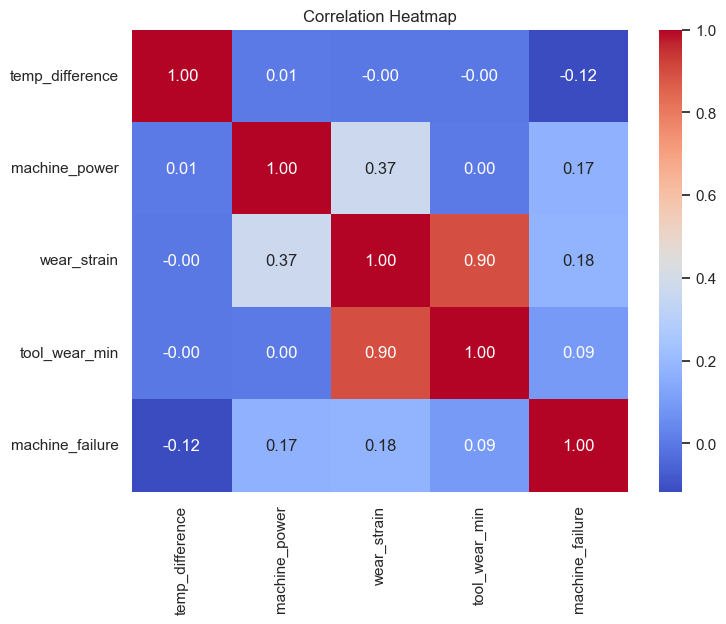

In [32]:
# Correlation between numeric engineered variables and the target
# The quality variable is categorical, so we do not include it in this correlation matrix.
engineered_corr_columns = [
    "temp_difference",
    "machine_power",
    "wear_strain",
    "tool_wear_min",
    "machine_failure"
]

correlation_matrix = train_fe[engineered_corr_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Model Training

In this section we train several classification models and compare two imbalance strategies:

1. **Class-weight strategy:** no resampling, but class weights are used where the model supports them.
2. **SMOTE + ENN strategy:** synthetic failure examples are created on the training folds and noisy boundary observations are cleaned with Edited Nearest Neighbours.

The main grid-search metric is **PR-AUC** (`average_precision`) because machine failures are rare. For each model and strategy, we use cross-validation on the training set to find the best hyperparameters.

In [33]:
# Modelling tools
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    brier_score_loss
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Compatibility patch for CatBoost with newer scikit-learn versions.
# Some CatBoost versions do not define __sklearn_tags__, which can crash GridSearchCV/cross_val_predict.
try:
    from sklearn.utils import Tags, TargetTags, ClassifierTags
except ImportError:
    try:
        from sklearn.utils._tags import Tags, TargetTags, ClassifierTags
    except ImportError:
        Tags = TargetTags = ClassifierTags = None

if Tags is not None and not hasattr(CatBoostClassifier, "__sklearn_tags__"):
    def _catboost_sklearn_tags(self):
        return Tags(
            estimator_type="classifier",
            target_tags=TargetTags(required=True),
            classifier_tags=ClassifierTags()
        )

    CatBoostClassifier.__sklearn_tags__ = _catboost_sklearn_tags

try:
    from imblearn.combine import SMOTEENN
    from imblearn.over_sampling import SMOTENC
    from imblearn.under_sampling import EditedNearestNeighbours
    from imblearn.pipeline import Pipeline as ImbPipeline
except ImportError as error:
    raise ImportError("Please install imbalanced-learn before running SMOTE + ENN models: pip install imbalanced-learn") from error

In [34]:
# Basic modelling settings
RANDOM_STATE = 42
CV_FOLDS = 5

numeric_features = [
    "temp_difference",
    "machine_power",
    "wear_strain",
    "tool_wear_min"
]

categorical_features = ["quality"]

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

negative_count = (y_train_fe == 0).sum()
positive_count = (y_train_fe == 1).sum()
scale_pos_weight = negative_count / positive_count

print(f"Scale positive weight: {scale_pos_weight:.2f}")

Scale positive weight: 28.56


In [35]:
# Preprocessing for models without resampling
standard_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

# Preprocessing before SMOTE + ENN.
# We ordinal-encode quality before SMOTENC, then one-hot encode it after resampling.
pre_smote_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OrdinalEncoder(), categorical_features)
    ]
)

post_smote_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", list(range(len(numeric_features)))),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), [len(numeric_features)])
    ]
)

In [36]:
# Models and small hyperparameter grids
model_configs = {
    "Logistic Regression": {
        "class_weight_model": LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        "smoteenn_model": LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "model__C": [0.1, 1, 10]
        }
    },
    "Random Forest": {
        "class_weight_model": RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "smoteenn_model": RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "param_grid": {
            "model__n_estimators": [100, 150, 200, 250],
            "model__max_depth": [5, 7, 10, None],
            "model__min_samples_leaf": [1, 5]
        }
    },
    "XGBoost": {
        "class_weight_model": XGBClassifier(
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "smoteenn_model": XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "param_grid": {
            "model__n_estimators": [100, 150, 200, 250],
            "model__max_depth": [3, 5, 6, 8],
            "model__learning_rate": [0.01, 0.05, 0.10]
        }
    },
    "LightGBM": {
        "class_weight_model": LGBMClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            verbose=-1,
            n_jobs=-1
        ),
        "smoteenn_model": LGBMClassifier(
            random_state=RANDOM_STATE,
            verbose=-1,
            n_jobs=-1
        ),
        "param_grid": {
            "model__n_estimators": [100, 150, 200, 250],
            "model__num_leaves": [15, 31, 40, 50, 60],
            "model__learning_rate": [0.01, 0.05, 0.10]
        }
    },
    "CatBoost": {
        "class_weight_model": CatBoostClassifier(
            auto_class_weights="Balanced",
            random_state=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False
        ),
        "smoteenn_model": CatBoostClassifier(
            random_state=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False
        ),
        "param_grid": {
            "model__iterations": [100, 150, 200, 250],
            "model__depth": [4, 5, 6, 8],
            "model__learning_rate": [0.01, 0.05, 0.10]
        }
    }
}

In [37]:
# Helper function for building pipelines
def build_pipeline(model, strategy):
    if strategy == "class_weight":
        return Pipeline(steps=[
            ("preprocess", standard_preprocessor),
            ("model", model)
        ])

    if strategy == "smoteenn":
        smote_nc = SMOTENC(
            categorical_features=[len(numeric_features)],
            random_state=RANDOM_STATE
        )

        sampler = SMOTEENN(
            smote=smote_nc,
            enn=EditedNearestNeighbours(),
            random_state=RANDOM_STATE
        )

        return ImbPipeline(steps=[
            ("preprocess_before_sampling", pre_smote_preprocessor),
            ("sampler", sampler),
            ("preprocess_after_sampling", post_smote_preprocessor),
            ("model", model)
        ])

    raise ValueError("Unknown strategy")

## Validation

For every model and imbalance strategy, we first choose hyperparameters using cross-validation PR-AUC on the training set. Then we use **out-of-fold training predictions** from the same cross-validation logic to choose the best probability threshold. The threshold is selected by maximizing the **F2-score**, because in predictive maintenance missing a real failure is usually more costly than making an additional inspection.

After the threshold is selected on the training folds, we evaluate each candidate on the separate validation set. This gives us a fair comparison of both the model and the imbalance strategy.

In [38]:
# Helper functions for threshold selection and validation metrics
def find_best_threshold(y_true, y_proba, beta=2):
    thresholds = np.linspace(0.01, 0.99, 99)
    rows = []

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        rows.append({
            "threshold": threshold,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "f2": fbeta_score(y_true, y_pred, beta=beta, zero_division=0)
        })

    threshold_results = pd.DataFrame(rows)
    best_row = threshold_results.sort_values("f2", ascending=False).iloc[0]

    return best_row["threshold"], threshold_results


def calculate_metrics(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "validation_pr_auc": average_precision_score(y_true, y_proba),
        "validation_roc_auc": roc_auc_score(y_true, y_proba),
        "validation_precision": precision_score(y_true, y_pred, zero_division=0),
        "validation_recall": recall_score(y_true, y_pred, zero_division=0),
        "validation_f1": f1_score(y_true, y_pred, zero_division=0),
        "validation_f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    }

In [39]:
# Train and validate every model-strategy combination
model_results = []
best_model_objects = {}
threshold_tables = {}

strategies = {
    "class_weight": "class_weight_model",
    "smoteenn": "smoteenn_model"
}

for model_name, config in model_configs.items():
    for strategy_name, model_key in strategies.items():
        print(f"Training: {model_name} | Strategy: {strategy_name}")

        # CatBoost needs n_jobs=1 with newer scikit-learn versions because its compatibility patch
        # is not always available inside parallel worker processes.
        parallel_jobs = 1 if model_name == "CatBoost" else -1

        pipeline = build_pipeline(
            model=config[model_key],
            strategy=strategy_name
        )

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=config["param_grid"],
            scoring="average_precision",
            cv=cv,
            n_jobs=parallel_jobs,
            refit=True
        )

        grid_search.fit(X_train_fe, y_train_fe)
        best_pipeline = grid_search.best_estimator_

        oof_proba = cross_val_predict(
            best_pipeline,
            X_train_fe,
            y_train_fe,
            cv=cv,
            method="predict_proba",
            n_jobs=parallel_jobs
        )[:, 1]

        best_threshold, threshold_results = find_best_threshold(
            y_true=y_train_fe,
            y_proba=oof_proba,
            beta=2
        )

        validation_proba = best_pipeline.predict_proba(X_valid_fe)[:, 1]
        validation_metrics = calculate_metrics(
            y_true=y_valid_fe,
            y_proba=validation_proba,
            threshold=best_threshold
        )

        result = {
            "model": model_name,
            "strategy": strategy_name,
            "cv_pr_auc": grid_search.best_score_,
            "best_threshold": best_threshold,
            "best_params": grid_search.best_params_
        }

        result.update(validation_metrics)
        model_results.append(result)

        key = (model_name, strategy_name)
        best_model_objects[key] = best_pipeline
        threshold_tables[key] = threshold_results

print("Training finished.")

Training: Logistic Regression | Strategy: class_weight
Training: Logistic Regression | Strategy: smoteenn
Training: Random Forest | Strategy: class_weight
Training: Random Forest | Strategy: smoteenn
Training: XGBoost | Strategy: class_weight
Training: XGBoost | Strategy: smoteenn
Training: LightGBM | Strategy: class_weight


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/

Training: LightGBM | Strategy: smoteenn


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/

Training: CatBoost | Strategy: class_weight
Training: CatBoost | Strategy: smoteenn
Training finished.


In [40]:
# Compare all trained candidates on the validation set
model_results_df = pd.DataFrame(model_results)

display_columns = [
    "model",
    "strategy",
    "cv_pr_auc",
    "validation_pr_auc",
    "validation_recall",
    "validation_precision",
    "validation_f2",
    "best_threshold",
    "false_positives",
    "false_negatives",
    "true_positives"
]

model_results_df[display_columns].sort_values(
    by=["validation_pr_auc", "validation_f2"],
    ascending=False
)

,model,strategy,cv_pr_auc,validation_pr_auc,validation_recall,validation_precision,validation_f2,best_threshold,false_positives,false_negatives,true_positives
7,LightGBM,smoteenn,0.765322,0.739804,0.691176,0.552941,0.658263,0.56,38,21,47
8,CatBoost,class_weight,0.749019,0.738074,0.750000,0.451327,0.662338,0.73,62,17,51
5,XGBoost,smoteenn,0.752048,0.731751,0.750000,0.346939,0.608592,0.48,96,17,51
2,Random Forest,class_weight,0.781123,0.728770,0.735294,0.505051,0.673854,0.16,49,18,50
9,CatBoost,smoteenn,0.736707,0.719490,0.705882,0.384000,0.604534,0.62,77,20,48
6,LightGBM,class_weight,0.786595,0.717317,0.750000,0.463636,0.667539,0.33,59,17,51
4,XGBoost,class_weight,0.770658,0.705370,0.691176,0.510870,0.645604,0.73,45,21,47
3,Random Forest,smoteenn,0.678490,0.658598,0.676471,0.446602,0.613333,0.53,57,22,46
0,Logistic Regression,class_weight,0.336830,0.299349,0.411765,0.247788,0.363636,0.72,85,40,28
1,Logistic Regression,smoteenn,0.322823,0.270325,0.426471,0.223077,0.360697,0.71,101,39,29


In [41]:
# Select the best model and strategy
# Primary criterion: validation PR-AUC
# Secondary criterion: validation F2-score
best_result = model_results_df.sort_values(
    by=["validation_pr_auc", "validation_f2"],
    ascending=False
).iloc[0]

best_model_name = best_result["model"]
best_strategy_name = best_result["strategy"]
best_threshold = best_result["best_threshold"]
best_model = best_model_objects[(best_model_name, best_strategy_name)]

print(f"Best model: {best_model_name}")
print(f"Best imbalance strategy: {best_strategy_name}")
print(f"Best threshold: {best_threshold:.2f}")
print(f"Validation PR-AUC: {best_result['validation_pr_auc']:.4f}")
print(f"Validation F2-score: {best_result['validation_f2']:.4f}")
print("Best hyperparameters:")
print(best_result["best_params"])

Best model: LightGBM
Best imbalance strategy: smoteenn
Best threshold: 0.56
Validation PR-AUC: 0.7398
Validation F2-score: 0.6583
Best hyperparameters:
{'model__learning_rate': 0.1, 'model__n_estimators': 150, 'model__num_leaves': 15}


## Retraining The Best Model

After selecting the best model and imbalance strategy on the validation set, we retrain this final candidate using both the training and validation data. The test set is still kept untouched and will be used only once for final evaluation.

We also recalculate the final threshold using cross-validated predictions on the combined train + validation data. This keeps threshold selection inside the development data and avoids using the test set for any decision.

In [42]:
# Combine train and validation data
train_valid_fe = pd.concat([train_fe, valid_fe], axis=0)

X_train_valid_fe = train_valid_fe.drop(columns="machine_failure")
y_train_valid_fe = train_valid_fe["machine_failure"]

print(f"Train + validation features shape: {X_train_valid_fe.shape}")
print(f"Train + validation target shape: {y_train_valid_fe.shape}")

Train + validation features shape: (8000, 5)
Train + validation target shape: (8000,)


In [43]:
from sklearn.base import clone

In [44]:
# Recalculate the threshold using out-of-fold predictions on train + validation data
final_model_for_threshold = clone(best_model)

final_oof_proba = cross_val_predict(
    final_model_for_threshold,
    X_train_valid_fe,
    y_train_valid_fe,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

final_threshold, final_threshold_table = find_best_threshold(
    y_true=y_train_valid_fe,
    y_proba=final_oof_proba,
    beta=2
)

print(f"Final threshold: {final_threshold:.2f}")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/

Final threshold: 0.61


In [45]:
# Retrain the selected model on train + validation data
final_model = clone(best_model)
final_model.fit(X_train_valid_fe, y_train_valid_fe)

print("Final model trained on train + validation data.")

Final model trained on train + validation data.


## Final Test Evaluation

The test set is evaluated only after the final model and threshold are fixed. These results represent the final estimate of how the selected model performs on unseen data.

In [46]:
# Predict failure probabilities on the test set
test_proba = final_model.predict_proba(X_test_fe)[:, 1]
test_pred = (test_proba >= final_threshold).astype(int)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [47]:
# Calculate final test metrics
test_metrics = calculate_metrics(
    y_true=y_test_fe,
    y_proba=test_proba,
    threshold=final_threshold
)

test_results = pd.DataFrame([{
    "model": best_model_name,
    "strategy": best_strategy_name,
    "threshold": final_threshold,
    **test_metrics
}])

test_results

,model,strategy,threshold,validation_pr_auc,validation_roc_auc,validation_precision,validation_recall,validation_f1,validation_f2,true_negatives,false_positives,false_negatives,true_positives
0,LightGBM,smoteenn,0.61,0.807742,0.973439,0.630952,0.779412,0.697368,0.744382,1901,31,15,53


In [48]:
# Show final confusion matrix
test_confusion_matrix = pd.DataFrame(
    confusion_matrix(y_test_fe, test_pred),
    index=["Actual no failure", "Actual failure"],
    columns=["Predicted no failure", "Predicted failure"]
)

test_confusion_matrix

,Predicted no failure,Predicted failure
Actual no failure,1901,31
Actual failure,15,53


In [49]:
# Store test predictions for later error analysis and XAI examples
test_predictions = X_test_fe.copy()
test_predictions["actual_failure"] = y_test_fe
test_predictions["predicted_probability"] = test_proba
test_predictions["predicted_failure"] = test_pred

test_predictions.head()

,temp_difference,machine_power,wear_strain,tool_wear_min,quality,actual_failure,predicted_probability,predicted_failure
3080,9.3,66484.8,5702.4,132,M,0,0.012528,0
735,11.5,50446.8,5605.2,173,L,0,0.004551,0
2681,9.7,49749.0,579.6,18,L,0,0.000310,0
32,10.4,68537.7,4395.3,91,L,0,0.004872,0
244,10.2,68494.5,10114.6,206,M,0,0.031178,0


## Model Reliability And Fairness

This section checks whether the model's probability scores and threshold choice are reliable, and whether performance differs across product quality groups.

### Threshold Impact Analysis

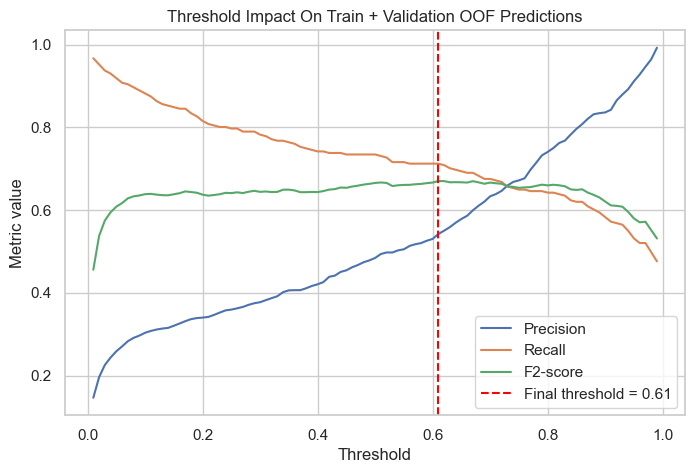

In [50]:
# Show how precision, recall, and F2-score change across thresholds
plt.figure(figsize=(8, 5))
plt.plot(final_threshold_table["threshold"], final_threshold_table["precision"], label="Precision")
plt.plot(final_threshold_table["threshold"], final_threshold_table["recall"], label="Recall")
plt.plot(final_threshold_table["threshold"], final_threshold_table["f2"], label="F2-score")
plt.axvline(final_threshold, color="red", linestyle="--", label=f"Final threshold = {final_threshold:.2f}")
plt.title("Threshold Impact On Train + Validation OOF Predictions")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.legend()
plt.show()

The threshold graph shows the trade-off between catching failures and avoiding false alarms. In our case the chosen threshold is a compromise where recall stays high, but precision is not ignored, which makes sense because failures are rare and missing them would be costly.

### Calibration Check

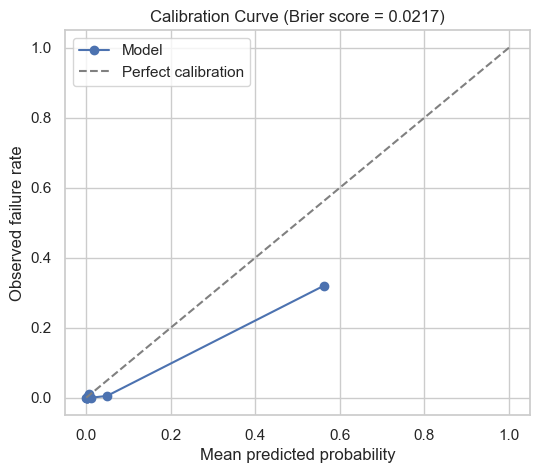

In [51]:
# Check whether predicted probabilities are well calibrated
prob_true, prob_pred = calibration_curve(
    y_test_fe,
    test_proba,
    n_bins=10,
    strategy="quantile"
)

brier = brier_score_loss(y_test_fe, test_proba)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.title(f"Calibration Curve (Brier score = {brier:.4f})")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed failure rate")
plt.legend()
plt.show()

The calibration plot shows that the predicted probabilities are useful for ranking risk, but they should still be treated as model scores rather than perfect real-world probabilities.

### Subgroup Performance By Product Quality

In [52]:
# Check model performance separately for each product quality group
quality_rows = []

for quality_value, group in test_predictions.groupby("quality", observed=True):
    y_true_group = group["actual_failure"]
    y_pred_group = group["predicted_failure"]
    y_proba_group = group["predicted_probability"]

    quality_rows.append({
        "quality": quality_value,
        "observations": len(group),
        "failures": y_true_group.sum(),
        "precision": precision_score(y_true_group, y_pred_group, zero_division=0),
        "recall": recall_score(y_true_group, y_pred_group, zero_division=0),
        "f2": fbeta_score(y_true_group, y_pred_group, beta=2, zero_division=0),
        "pr_auc": average_precision_score(y_true_group, y_proba_group) if y_true_group.nunique() > 1 else np.nan
    })

quality_performance = pd.DataFrame(quality_rows)
quality_performance

,quality,observations,failures,precision,recall,f2,pr_auc
0,H,198,3,0.666667,0.666667,0.666667,0.866667
1,L,1179,41,0.615385,0.780488,0.740741,0.833939
2,M,623,24,0.655172,0.791667,0.760000,0.765823


In [53]:
# Confusion-matrix counts by product quality
quality_confusion_rows = []

for quality_value, group in test_predictions.groupby("quality", observed=True):
    tn, fp, fn, tp = confusion_matrix(
        group["actual_failure"],
        group["predicted_failure"],
        labels=[0, 1]
    ).ravel()

    quality_confusion_rows.append({
        "quality": quality_value,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    })

quality_confusion = pd.DataFrame(quality_confusion_rows)
quality_confusion

,quality,true_negatives,false_positives,false_negatives,true_positives
0,H,194,1,1,2
1,L,1118,20,9,32
2,M,589,10,5,19


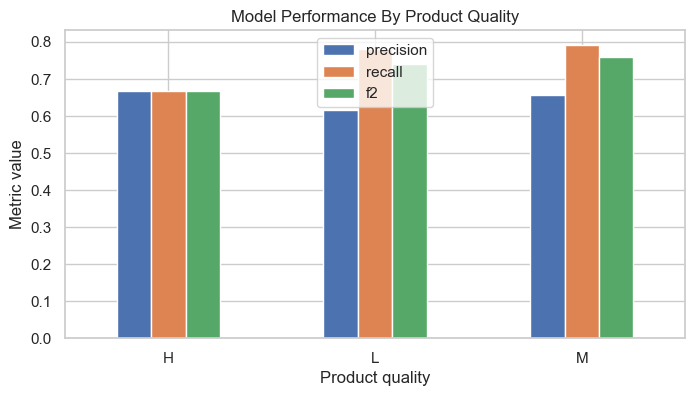

In [54]:
# Plot subgroup metrics by product quality
quality_performance.set_index("quality")[["precision", "recall", "f2"]].plot(kind="bar", figsize=(8, 4))
plt.title("Model Performance By Product Quality")
plt.xlabel("Product quality")
plt.ylabel("Metric value")
plt.xticks(rotation=0)
plt.show()

Performance is fairly similar for product qualities L and M, so the model does not look clearly biased toward only one of these groups. The H group has only a few failures, so its metrics are less stable and should not be overinterpreted.

## Global XAI

Global XAI methods explain how the final model behaves overall. In this part, we focus on the final retrained model and the engineered features used for modelling.

### XAI Imports And Settings

In [55]:
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

figures_dir = data_dir.parent / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

try:
    import shap
except ImportError:
    shap = None
    print("SHAP is not installed. Install it with: pip install shap")

### Permutation Feature Importance

In [56]:
# Permutation importance checks how much PR-AUC drops when each feature is shuffled.
permutation_result = permutation_importance(
    final_model,
    X_test_fe,
    y_test_fe,
    scoring="average_precision",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "feature": X_test_fe.columns,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std
}).sort_values("importance_mean", ascending=False)

permutation_importance_df

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/

,feature,importance_mean,importance_std
1,machine_power,0.552533,0.022526
2,wear_strain,0.346059,0.015190
0,temp_difference,0.232884,0.015818
4,quality,0.100721,0.020570
3,tool_wear_min,0.050907,0.011408


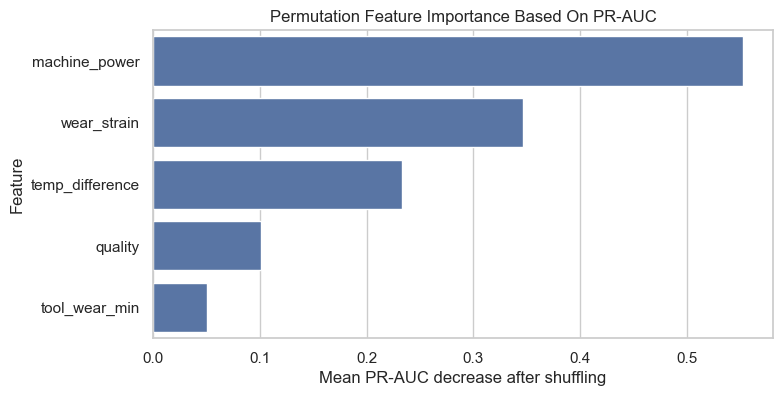

In [57]:
# Plot permutation importance
plt.figure(figsize=(8, 4))
sns.barplot(
    data=permutation_importance_df,
    x="importance_mean",
    y="feature"
)
plt.title("Permutation Feature Importance Based On PR-AUC")
plt.xlabel("Mean PR-AUC decrease after shuffling")
plt.ylabel("Feature")
plt.savefig(figures_dir / "permutation_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

The permutation importance results show a clear advantage of `machine_power`, because shuffling this feature causes the largest drop in PR-AUC. `wear_strain` is also much higher than `tool_wear_min`, which is actually the last feature in this ranking. For me, the main takeaway is that high tool wear alone does not automatically mean failure. The model cares more about wear combined with mechanical stress (torque). `temp_difference` is also important and stays in the top part of the ranking, so thermal behavior should not be ignored.

### SHAP Global Explanation

In [58]:
# SHAP setup for model-agnostic explanations.
# SHAP permutation explainer needs numeric inputs, so we encode quality for SHAP only.
# The prediction function converts quality back to L/M/H before using the final model.
if shap is not None:
    quality_to_number = {"L": 0, "M": 1, "H": 2}
    number_to_quality = {0: "L", 1: "M", 2: "H"}
    shap_feature_names = numeric_features + ["quality"]

    def encode_quality_for_shap(data):
        data_encoded = data.copy()
        data_encoded["quality"] = data_encoded["quality"].astype(str).map(quality_to_number)
        return data_encoded[shap_feature_names]

    def prepare_shap_data(data):
        data_df = pd.DataFrame(data, columns=shap_feature_names).copy()

        for column in numeric_features:
            data_df[column] = pd.to_numeric(data_df[column])

        quality_code = pd.to_numeric(data_df["quality"]).round().clip(0, 2).astype(int)
        data_df["quality"] = quality_code.map(number_to_quality).astype("category")

        return data_df

    def predict_failure_probability(data):
        data_df = prepare_shap_data(data)
        return final_model.predict_proba(data_df)[:, 1]

    shap_background = X_train_valid_fe.sample(
        n=min(100, len(X_train_valid_fe)),
        random_state=RANDOM_STATE
    )

    shap_sample_original = X_test_fe.sample(
        n=min(150, len(X_test_fe)),
        random_state=RANDOM_STATE
    )

    shap_background = encode_quality_for_shap(shap_background)
    shap_sample = encode_quality_for_shap(shap_sample_original)

    shap_explainer = shap.Explainer(
        predict_failure_probability,
        shap_background,
        algorithm="permutation"
    )

    shap_values = shap_explainer(shap_sample, max_evals=200)
else:
    print("Skipping SHAP setup because SHAP is not installed.")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/

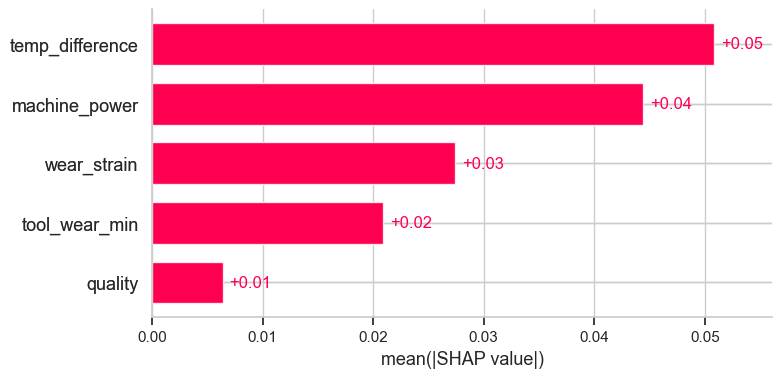

In [59]:
# SHAP global importance plot
if shap is not None:
    shap.plots.bar(shap_values, max_display=10, show=False)
    plt.savefig(figures_dir / "shap_global_importance.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Install SHAP to show this plot.")

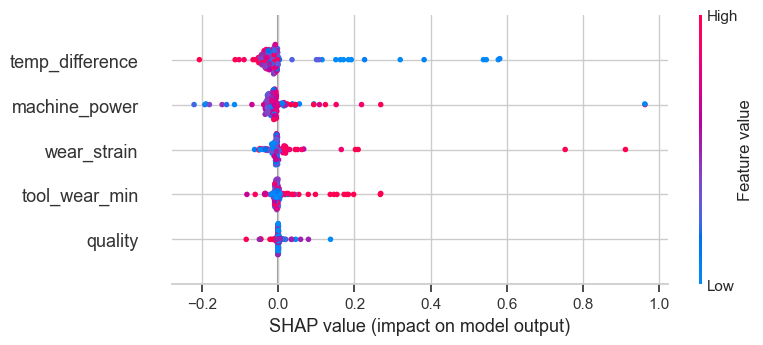

In [60]:
# SHAP beeswarm plot: feature importance and direction of influence
if shap is not None:
    shap.plots.beeswarm(shap_values, max_display=10, show=False)
    plt.savefig(figures_dir / "shap_beeswarm.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Install SHAP to show this plot.")

The global SHAP scores tell a similar story, although the ranking is not exactly the same as in permutation importance. SHAP gives high average influence to `temp_difference`, `machine_power`, and `wear_strain`, while `tool_wear_min` and `quality` have smaller effects. So both methods point to combined operating stress as the key part of the model, but they look at importance from slightly different angles.

### Partial Dependence Plots

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/

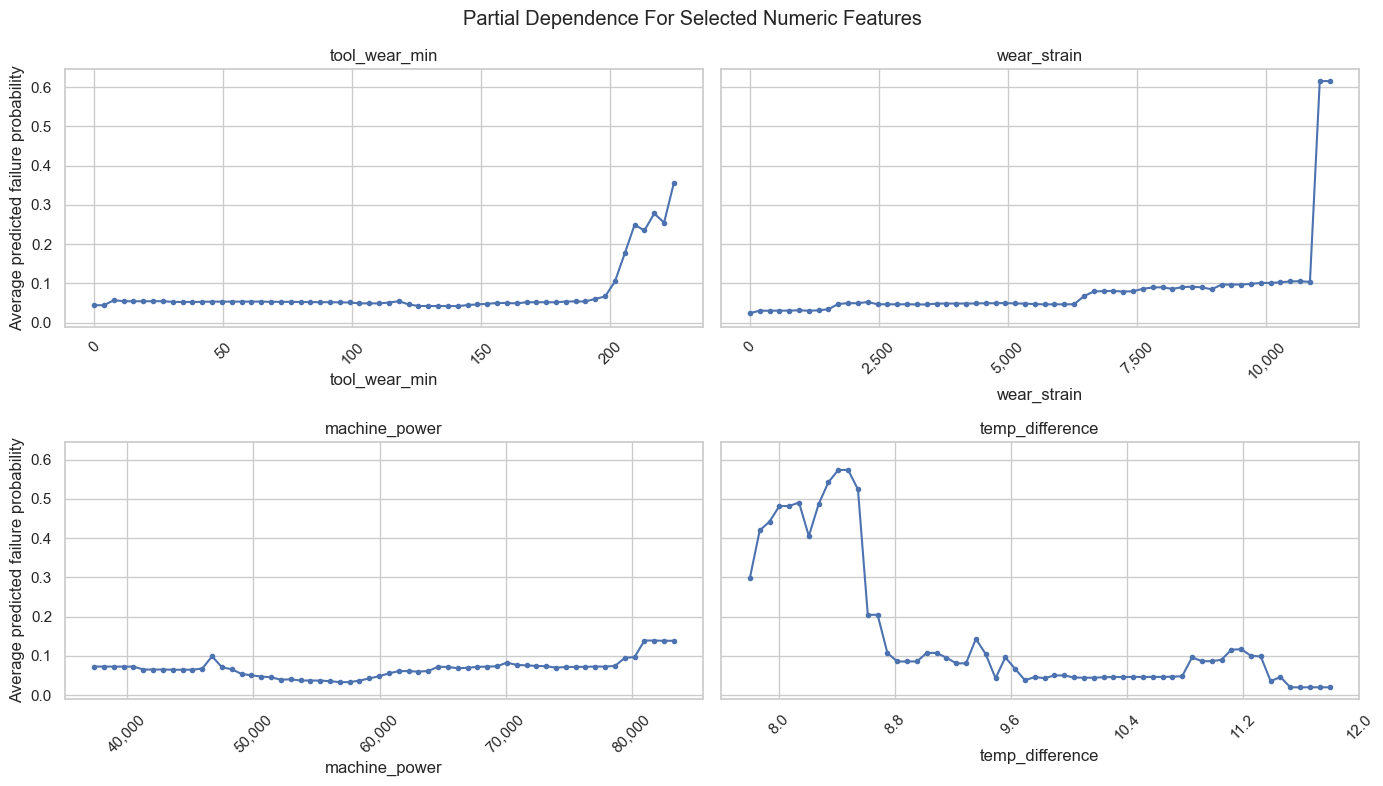

,feature,rank,feature_value,average_predicted_probability
0,tool_wear_min,1,224.598000,0.356026
1,tool_wear_min,2,216.984508,0.277891
2,tool_wear_min,3,220.791254,0.254556
3,wear_strain,1,11231.721600,0.615161
4,wear_strain,2,11041.353437,0.615161
5,wear_strain,3,10660.617112,0.105170
6,machine_power,1,81775.628092,0.138832
7,machine_power,2,80996.569037,0.138832
8,machine_power,3,83333.746200,0.138213
9,temp_difference,1,8.477966,0.573475


In [61]:
# PDP for selected numeric features
# We calculate the PDP manually so the x-axis labels are easier to read.
from sklearn.inspection import partial_dependence
from matplotlib.ticker import MaxNLocator, StrMethodFormatter, FormatStrFormatter

pdp_features = [
    "tool_wear_min",
    "wear_strain",
    "machine_power",
    "temp_difference"
]

# PDP may test decimal values even for originally integer columns such as tool_wear_min.
# Casting these columns to float avoids dtype errors during the PDP calculation.
X_pdp = X_test_fe.copy()
X_pdp[pdp_features] = X_pdp[pdp_features].astype(float)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()
pdp_peak_rows = []

for ax, feature in zip(axes, pdp_features):
    pdp_result = partial_dependence(
        final_model,
        X_pdp,
        features=[feature],
        kind="average",
        response_method="predict_proba",
        grid_resolution=60,
        percentiles=(0.01, 0.99)
    )

    grid_key = "grid_values" if "grid_values" in pdp_result else "values"
    grid_values = pdp_result[grid_key][0]
    pdp_values = pdp_result["average"][0]

    ax.plot(grid_values, pdp_values, marker="o", markersize=3)
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.tick_params(axis="x", rotation=45)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))

    if feature == "temp_difference":
        ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    else:
        ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

    if feature in ["tool_wear_min", "machine_power"]:
        ax.set_ylabel("Average predicted failure probability")

    top_positions = np.argsort(pdp_values)[-3:][::-1]
    for rank, position in enumerate(top_positions, start=1):
        pdp_peak_rows.append({
            "feature": feature,
            "rank": rank,
            "feature_value": grid_values[position],
            "average_predicted_probability": pdp_values[position]
        })

plt.suptitle("Partial Dependence For Selected Numeric Features")
plt.tight_layout()
plt.savefig(figures_dir / "partial_dependence_numeric_features.png", dpi=300, bbox_inches="tight")
plt.show()

pdp_peak_values = pd.DataFrame(pdp_peak_rows)
pdp_peak_values

The PDP plots show how the model average prediction changes when one feature is moved across its range, so this should be interpreted as model behavior, not direct causality. `tool_wear_min` becomes more risky at high wear values, but the effect is much clearer when wear is combined with torque in `wear_strain`. `machine_power` also has visible higher-risk ranges, which supports using it as an early warning signal. The strongest PDP pattern is for `temp_difference`: the predicted risk is high across a lower range around roughly 8.3-8.5 K, not just at one single spike, so low temperature difference looks like an important warning area in this model.

## Local XAI

Local XAI methods explain individual predictions. We choose examples from the test set: a true positive, true negative, false positive, and false negative when available.

### Selecting Individual Cases

In [62]:
# Select representative cases for local explanations
case_rules = {
    "true_positive": (1, 1),
    "true_negative": (0, 0),
    "false_positive": (0, 1),
    "false_negative": (1, 0)
}

selected_case_indices = []

for case_name, (actual_value, predicted_value) in case_rules.items():
    matching_cases = test_predictions[
        (test_predictions["actual_failure"] == actual_value) &
        (test_predictions["predicted_failure"] == predicted_value)
    ]

    if not matching_cases.empty:
        if predicted_value == 1:
            selected_index = matching_cases["predicted_probability"].idxmax()
        else:
            selected_index = matching_cases["predicted_probability"].idxmin()

        selected_case_indices.append(selected_index)
        print(f"{case_name}: selected index {selected_index}")
    else:
        print(f"{case_name}: no case found")

selected_cases = test_predictions.loc[selected_case_indices].copy()

# Additional high-confidence correct examples
extra_cases_per_group = 2

extra_true_negatives = (
    test_predictions[
        (test_predictions["actual_failure"] == 0) &
        (test_predictions["predicted_failure"] == 0)
    ]
    .drop(index=selected_case_indices, errors="ignore")
    .nsmallest(extra_cases_per_group, "predicted_probability")
    .copy()
)
extra_true_negatives["case_type"] = "extra_very_low_risk_true_negative"

extra_true_positives = (
    test_predictions[
        (test_predictions["actual_failure"] == 1) &
        (test_predictions["predicted_failure"] == 1)
    ]
    .drop(index=selected_case_indices, errors="ignore")
    .nlargest(extra_cases_per_group, "predicted_probability")
    .copy()
)
extra_true_positives["case_type"] = "extra_very_high_risk_true_positive"

extra_local_cases = pd.concat([extra_true_negatives, extra_true_positives])
extra_case_indices = extra_local_cases.index.tolist()

print()
print("Main representative cases:")
display(selected_cases)

print("Extra high-confidence correct cases:")
extra_local_cases

true_positive: selected index 3943
true_negative: selected index 7427
false_positive: selected index 7677
false_negative: selected index 4833

Main representative cases:


,temp_difference,machine_power,wear_strain,tool_wear_min,quality,actual_failure,predicted_probability,predicted_failure
3943,9.1,88911.1,13673.5,205,L,1,0.999962,1
7427,11.4,52124.6,0.0,0,L,0,0.000028,0
7677,11.1,75112.8,10940.8,208,L,0,0.948278,1
4833,8.5,57283.2,1414.4,34,L,1,0.003663,0


Extra high-confidence correct cases:


,temp_difference,machine_power,wear_strain,tool_wear_min,quality,actual_failure,predicted_probability,predicted_failure,case_type
1262,11.4,54384.0,957.0,29,H,0,0.000037,0,extra_very_low_risk_true_negative
9672,11.2,54936.0,0.0,0,H,0,0.000048,0,extra_very_low_risk_true_negative
6540,9.3,87141.6,5860.4,92,M,1,0.999594,1,extra_very_high_risk_true_positive
7011,10.0,32122.6,207.4,17,L,1,0.999565,1,extra_very_high_risk_true_positive


### SHAP Local Explanations

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/

Main representative cases
Case index: 3943 | actual: 1 | predicted: 1 | probability: 1.000


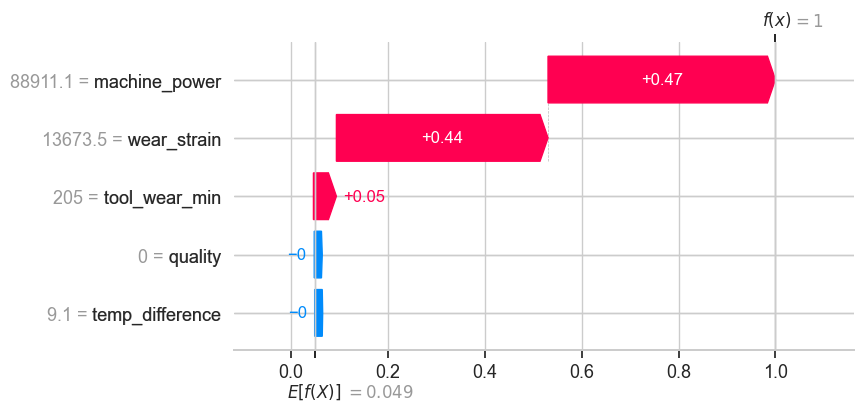

Case index: 7427 | actual: 0 | predicted: 0 | probability: 0.000


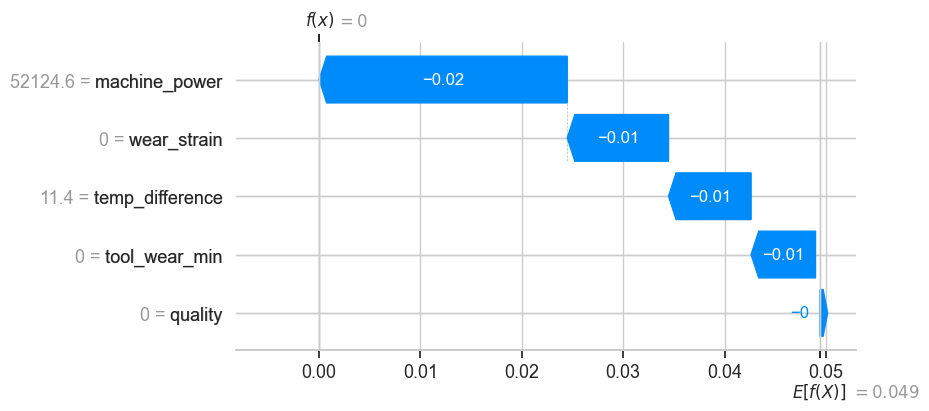

Case index: 7677 | actual: 0 | predicted: 1 | probability: 0.948


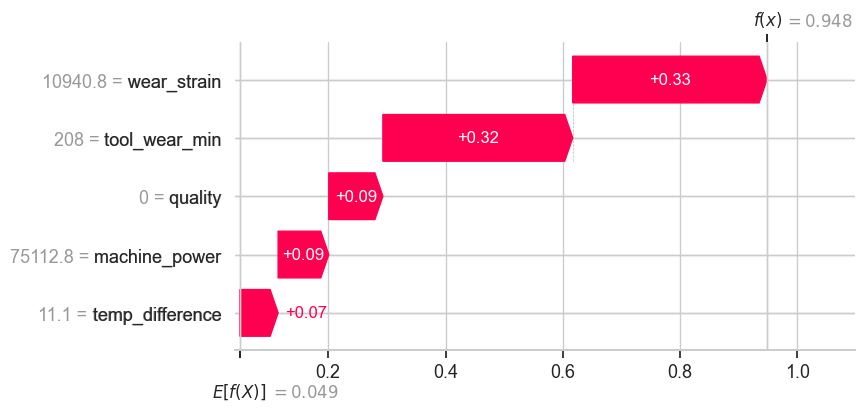

Case index: 4833 | actual: 1 | predicted: 0 | probability: 0.004


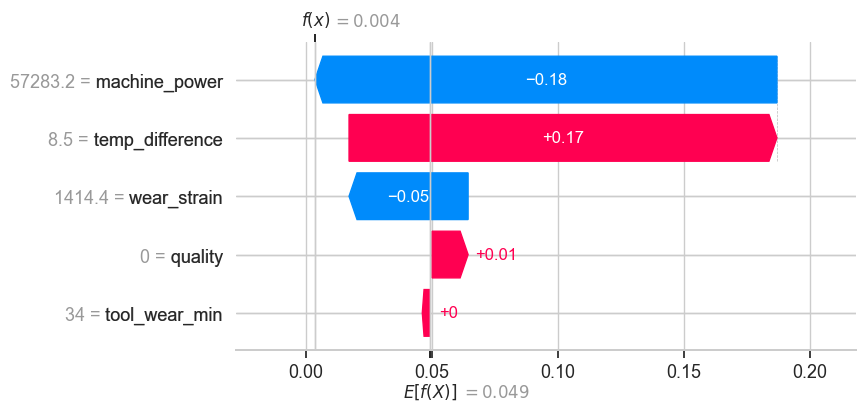

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/

Extra high-confidence correct cases
extra_very_low_risk_true_negative | case index: 1262 | actual: 0 | predicted: 0 | probability: 0.000


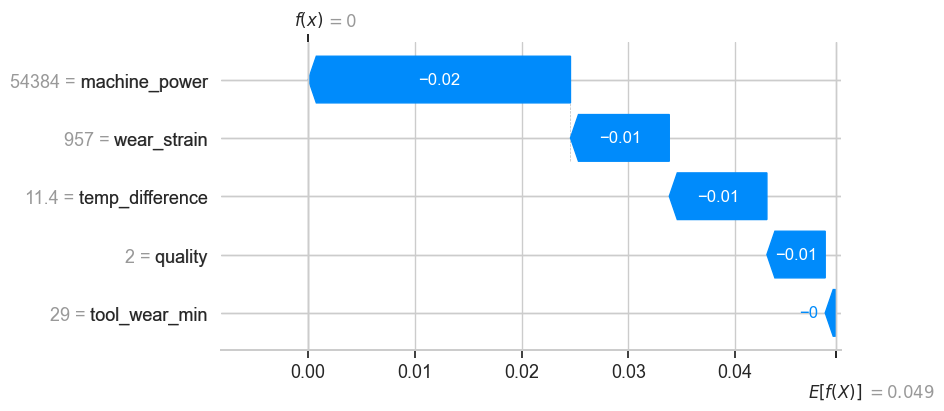

extra_very_low_risk_true_negative | case index: 9672 | actual: 0 | predicted: 0 | probability: 0.000


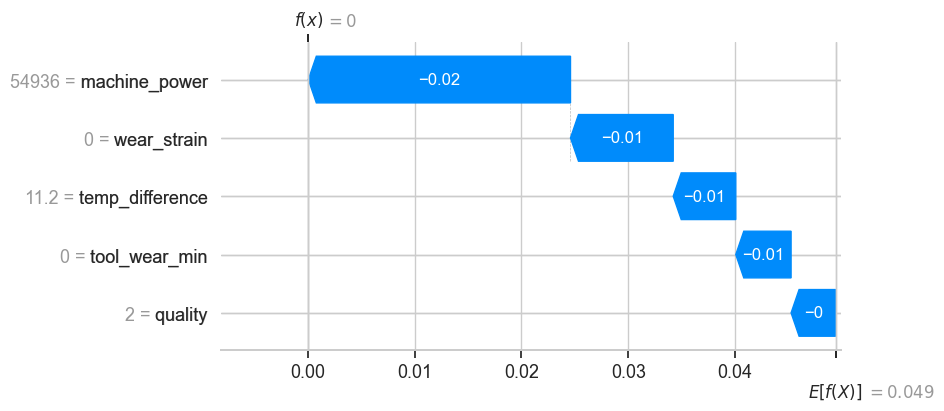

extra_very_high_risk_true_positive | case index: 6540 | actual: 1 | predicted: 1 | probability: 1.000


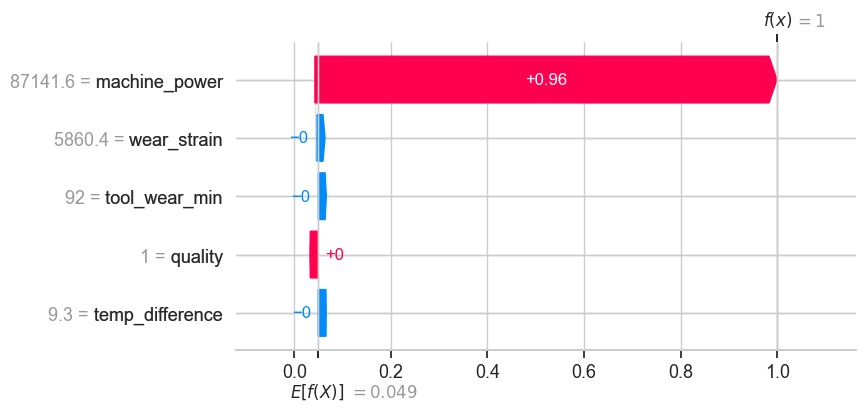

extra_very_high_risk_true_positive | case index: 7011 | actual: 1 | predicted: 1 | probability: 1.000


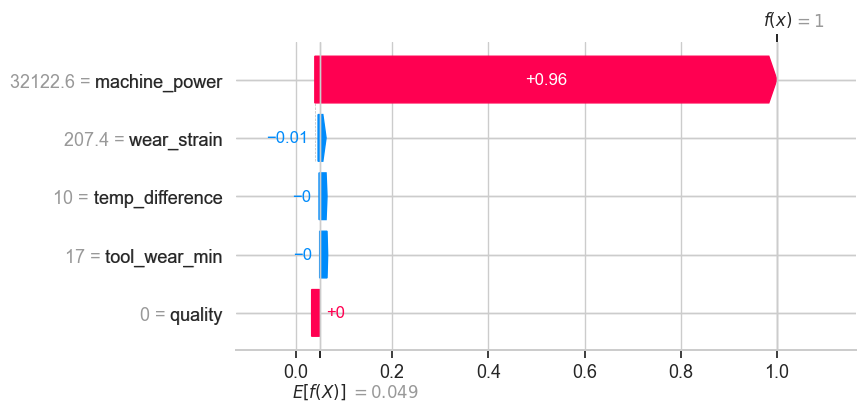

In [63]:
# SHAP waterfall plots for selected individual predictions
if shap is not None:
    local_cases_original = X_test_fe.loc[selected_case_indices].copy()
    local_cases = encode_quality_for_shap(local_cases_original)

    local_shap_values = shap_explainer(local_cases, max_evals=200)

    print("Main representative cases")
    for position, case_index in enumerate(local_cases.index):
        actual = test_predictions.loc[case_index, "actual_failure"]
        predicted = test_predictions.loc[case_index, "predicted_failure"]
        probability = test_predictions.loc[case_index, "predicted_probability"]

        print(f"Case index: {case_index} | actual: {actual} | predicted: {predicted} | probability: {probability:.3f}")
        shap.plots.waterfall(local_shap_values[position], max_display=10, show=False)
        plt.savefig(figures_dir / f"shap_waterfall_case_{case_index}.png", dpi=300, bbox_inches="tight")
        plt.show()

    if extra_case_indices:
        extra_cases_original = X_test_fe.loc[extra_case_indices].copy()
        extra_cases = encode_quality_for_shap(extra_cases_original)
        extra_shap_values = shap_explainer(extra_cases, max_evals=200)

        print("Extra high-confidence correct cases")
        for position, case_index in enumerate(extra_cases.index):
            case_type = extra_local_cases.loc[case_index, "case_type"]
            actual = test_predictions.loc[case_index, "actual_failure"]
            predicted = test_predictions.loc[case_index, "predicted_failure"]
            probability = test_predictions.loc[case_index, "predicted_probability"]

            print(f"{case_type} | case index: {case_index} | actual: {actual} | predicted: {predicted} | probability: {probability:.3f}")
            shap.plots.waterfall(extra_shap_values[position], max_display=10, show=False)
            plt.savefig(figures_dir / f"shap_waterfall_{case_type}_case_{case_index}.png", dpi=300, bbox_inches="tight")
            plt.show()
else:
    print("Install SHAP to show local explanations.")

The local SHAP plots confirm that `machine_power` can strongly push an individual prediction toward failure or away from failure. In high-risk cases, `wear_strain` also often adds a lot of risk, which again suggests that the model reacts to combined stress rather than only to one simple variable. Low-risk examples usually have features pushing the score down, especially when power and strain are not in dangerous ranges.

### Simple Counterfactual / What-If Explanation

In this what-if analysis, `current situation` is the original machine case. The other rows keep the same case but change one or more operating conditions to safer or more typical values from the training data. The combined tool-maintenance scenario lowers both tool wear and wear strain together, because these two features are mechanically connected. Median power and median temperature difference use the middle value from the training data.

In [64]:
# Simple what-if analysis for two predicted-failure cases.
# 1. highest-risk predicted failure
# 2. borderline predicted failure closest to the final threshold

predicted_failure_cases = test_predictions[test_predictions["predicted_failure"] == 1].copy()

if predicted_failure_cases.empty:
    selected_counterfactual_indices = [test_predictions["predicted_probability"].idxmax()]
else:
    highest_risk_index = predicted_failure_cases["predicted_probability"].idxmax()

    predicted_failure_cases["distance_to_threshold"] = (
        predicted_failure_cases["predicted_probability"] - final_threshold
    ).abs()
    borderline_index = predicted_failure_cases["distance_to_threshold"].idxmin()

    selected_counterfactual_indices = list(dict.fromkeys([highest_risk_index, borderline_index]))


safe_values = {
    "low_tool_wear": X_train_valid_fe["tool_wear_min"].quantile(0.25),
    "low_wear_strain": X_train_valid_fe["wear_strain"].quantile(0.25),
    "median_machine_power": X_train_valid_fe["machine_power"].median(),
    "median_temp_difference": X_train_valid_fe["temp_difference"].median()
}

positive_tool_wear = X_train_valid_fe["tool_wear_min"] > 0
typical_torque_estimate = (
    X_train_valid_fe.loc[positive_tool_wear, "wear_strain"] /
    X_train_valid_fe.loc[positive_tool_wear, "tool_wear_min"]
).median()


def estimate_torque_from_engineered_features(row):
    tool_wear = row["tool_wear_min"].iloc[0]
    wear_strain = row["wear_strain"].iloc[0]

    if tool_wear > 0:
        return wear_strain / tool_wear
    return typical_torque_estimate


def get_failure_probability(row):
    return final_model.predict_proba(row)[:, 1][0]


counterfactual_rows = []

for case_index in selected_counterfactual_indices:
    base_row = X_test_fe.loc[[case_index]].copy()
    base_probability = get_failure_probability(base_row)
    estimated_torque = estimate_torque_from_engineered_features(base_row)

    current_tool_wear = base_row["tool_wear_min"].iloc[0]
    current_wear_strain = base_row["wear_strain"].iloc[0]

    lower_tool_wear_value = min(current_tool_wear, safe_values["low_tool_wear"])
    lower_wear_strain_value = min(current_wear_strain, safe_values["low_wear_strain"])

    scenarios = {
        "current situation - no changes": {
            "row": base_row.copy(),
            "what_changed": "nothing changed"
        }
    }

    newer_tool_and_lower_load_row = base_row.copy()
    newer_tool_and_lower_load_row["tool_wear_min"] = lower_tool_wear_value
    newer_tool_and_lower_load_row["wear_strain"] = min(
        lower_tool_wear_value * estimated_torque,
        lower_wear_strain_value
    )
    scenarios["tool maintenance: newer tool and lower wear strain"] = {
        "row": newer_tool_and_lower_load_row,
        "what_changed": "tool wear and wear strain lowered together"
    }

    median_power_row = base_row.copy()
    median_power_row["machine_power"] = safe_values["median_machine_power"]
    scenarios["machine power set to median"] = {
        "row": median_power_row,
        "what_changed": "machine power replaced with the training-set median"
    }

    median_temp_row = base_row.copy()
    median_temp_row["temp_difference"] = safe_values["median_temp_difference"]
    scenarios["temperature difference set to median"] = {
        "row": median_temp_row,
        "what_changed": "temperature difference replaced with the training-set median"
    }

    maintenance_plan_row = base_row.copy()
    maintenance_plan_row["tool_wear_min"] = lower_tool_wear_value
    maintenance_plan_row["wear_strain"] = min(
        lower_tool_wear_value * estimated_torque,
        lower_wear_strain_value
    )
    maintenance_plan_row["machine_power"] = safe_values["median_machine_power"]
    maintenance_plan_row["temp_difference"] = safe_values["median_temp_difference"]
    scenarios["full maintenance plan: tool maintenance, median power and temperature"] = {
        "row": maintenance_plan_row,
        "what_changed": "tool wear and wear strain lowered; power and temperature difference set to medians"
    }

    for scenario_name, scenario_info in scenarios.items():
        scenario_row = scenario_info["row"]
        probability = get_failure_probability(scenario_row)

        counterfactual_rows.append({
            "case_index": case_index,
            "actual_failure": test_predictions.loc[case_index, "actual_failure"],
            "scenario": scenario_name,
            "what_changed": scenario_info["what_changed"],
            "predicted_probability": probability,
            "probability_change": probability - base_probability,
            "predicted_failure": int(probability >= final_threshold)
        })

counterfactual_results = pd.DataFrame(counterfactual_rows)
counterfactual_results

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/

,case_index,actual_failure,scenario,what_changed,predicted_probability,probability_change,predicted_failure
0,3943,1,current situation - no changes,nothing changed,0.999962,0.000000,1
1,3943,1,tool maintenance: newer tool and lower wear st...,tool wear and wear strain lowered together,0.999109,-0.000853,1
2,3943,1,machine power set to median,machine power replaced with the training-set m...,0.980756,-0.019206,1
3,3943,1,temperature difference set to median,temperature difference replaced with the train...,0.999946,-0.000016,1
4,3943,1,"full maintenance plan: tool maintenance, media...",tool wear and wear strain lowered; power and t...,0.001077,-0.998885,0
5,1592,0,current situation - no changes,nothing changed,0.613360,0.000000,1
6,1592,0,tool maintenance: newer tool and lower wear st...,tool wear and wear strain lowered together,0.002628,-0.610732,0
7,1592,0,machine power set to median,machine power replaced with the training-set m...,0.682141,0.068781,1
8,1592,0,temperature difference set to median,temperature difference replaced with the train...,0.285440,-0.327919,0
9,1592,0,"full maintenance plan: tool maintenance, media...",tool wear and wear strain lowered; power and t...,0.001077,-0.612283,0


The what-if results suggest that changing only one condition does not always reduce the risk enough. The biggest changes usually appear when several operating conditions are improved together, which fits the idea that machine failure is connected with the whole operating state, not one isolated measurement.

### Project Conclusions

The final model is able to identify rare failure cases quite well, which is the most important part of this classification task. From the XAI results, the first business recommendation is to monitor combined stress, not tool wear alone, because `wear_strain` and `machine_power` are more informative than simple wear time. The second recommendation is to watch low `temp_difference`, because the model shows a clear risk increase in the lower temperature-difference range. The third recommendation is to prioritize `machine_power` as an early warning signal, since it is the strongest feature in permutation importance. Overall, the model could be used as a maintenance support tool that helps decide which machines need attention first.